# Expected revenue model :
### Emma and lucy 


#### import all necessary libraries


In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [16]:
from pathlib import Path
import pandas as pd

# go up 2 folders: expected_revenue → models → project root
BASE_DIR = Path.cwd().parents[1]

DATA_DIR = BASE_DIR / "data"

print("Base dir:", BASE_DIR)
print("Data dir:", DATA_DIR)
print("Exists:", DATA_DIR.exists())

Base dir: c:\Users\Emma Davidson\ID5059\Coursework p2\Machine-Learning-Taxi-
Data dir: c:\Users\Emma Davidson\ID5059\Coursework p2\Machine-Learning-Taxi-\data
Exists: True


In [17]:
# Load the dataset
from pathlib import Path # this is for handling the data file paths in a more flexible way
file_path = DATA_DIR / "nyc_taxi_2024-01.csv"

print(file_path)
print(file_path.exists())

df = pd.read_csv(
    file_path,
    parse_dates=["tpep_pickup_datetime", "tpep_dropoff_datetime"]
)

print(df.shape)
df.head()

c:\Users\Emma Davidson\ID5059\Coursework p2\Machine-Learning-Taxi-\data\nyc_taxi_2024-01.csv
True


C:\Users\Emma Davidson\AppData\Local\Temp\ipykernel_9380\851619371.py:8: DtypeWarning: Columns (0: store_and_fwd_flag) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


(2964624, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,10.0,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,7.9,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.0


#### now we will use a multi month 

In [19]:
def load_taxi_data(month_start=1, month_end=3):
    frames = []

    for month in range(month_start, month_end + 1):
        file_path = DATA_DIR / f"nyc_taxi_2024-{month:02d}.csv"
        print("Loading:", file_path)

        if not file_path.exists():
            raise FileNotFoundError(f"Missing file: {file_path}")

        temp = pd.read_csv(
            file_path,
            parse_dates=["tpep_pickup_datetime", "tpep_dropoff_datetime"]
        )
        temp["month"] = month
        frames.append(temp)

    return pd.concat(frames, ignore_index=True)

df = load_taxi_data(1, 3)
print(df.shape)

Loading: c:\Users\Emma Davidson\ID5059\Coursework p2\Machine-Learning-Taxi-\data\nyc_taxi_2024-01.csv


C:\Users\Emma Davidson\AppData\Local\Temp\ipykernel_9380\4132794442.py:11: DtypeWarning: Columns (0: store_and_fwd_flag) have mixed types. Specify dtype option on import or set low_memory=False.
  temp = pd.read_csv(


Loading: c:\Users\Emma Davidson\ID5059\Coursework p2\Machine-Learning-Taxi-\data\nyc_taxi_2024-02.csv


C:\Users\Emma Davidson\AppData\Local\Temp\ipykernel_9380\4132794442.py:11: DtypeWarning: Columns (0: store_and_fwd_flag) have mixed types. Specify dtype option on import or set low_memory=False.
  temp = pd.read_csv(


Loading: c:\Users\Emma Davidson\ID5059\Coursework p2\Machine-Learning-Taxi-\data\nyc_taxi_2024-03.csv


C:\Users\Emma Davidson\AppData\Local\Temp\ipykernel_9380\4132794442.py:11: DtypeWarning: Columns (0: store_and_fwd_flag) have mixed types. Specify dtype option on import or set low_memory=False.
  temp = pd.read_csv(


(9554778, 20)


finding the features to use

In [23]:
candidate_features = [
    "trip_distance",
    "passenger_count",
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_month",
    "trip_duration_minutes",
    "fare_amount",
    "total_amount"
]

df_subset = df[candidate_features].copy()
df_subset.head()

,trip_distance,passenger_count,pickup_hour,pickup_dayofweek,pickup_month,trip_duration_minutes,fare_amount,total_amount
0,1.72,1.0,0,0,1,19.800000,17.7,22.70
1,1.80,1.0,0,0,1,6.600000,10.0,18.75
2,4.70,1.0,0,0,1,17.916667,23.3,31.30
3,1.40,1.0,0,0,1,8.300000,10.0,17.00
4,0.80,1.0,0,0,1,6.100000,7.9,16.10


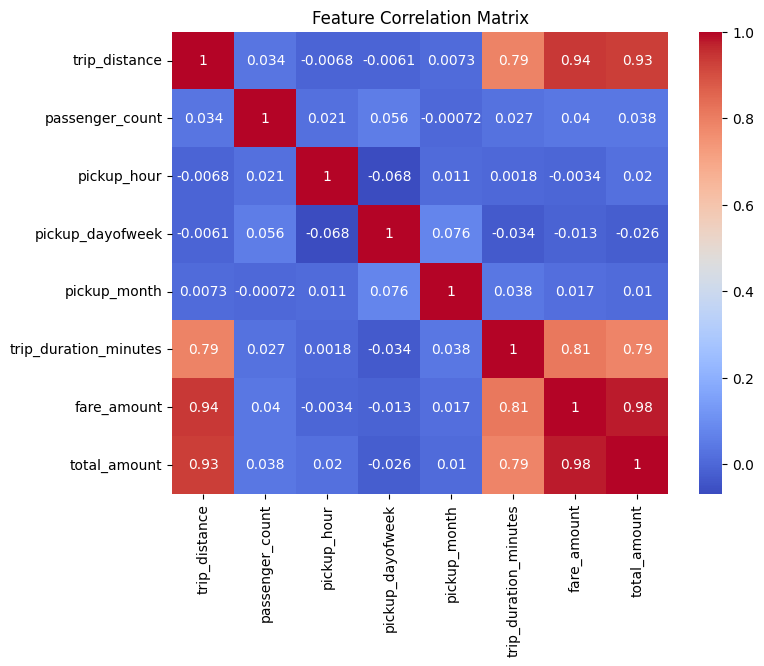

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_subset.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [20]:
df["pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

df["trip_duration_minutes"] = (
    df["dropoff_datetime"] - df["pickup_datetime"]
).dt.total_seconds() / 60

df["pickup_hour"] = df["pickup_datetime"].dt.hour
df["pickup_dayofweek"] = df["pickup_datetime"].dt.dayofweek
df["pickup_month"] = df["pickup_datetime"].dt.month

df["is_weekend"] = df["pickup_dayofweek"].isin([5, 6]).astype(int)

#### Data cleaning - sups important

In [21]:
df = df[
    (df["trip_distance"] > 0) &
    (df["trip_duration_minutes"] > 0) &
    (df["fare_amount"] > 0) &
    (df["total_amount"] > 0)
].copy()

# Remove extreme outliers
df = df[
    (df["trip_distance"] < 100) &
    (df["trip_duration_minutes"] < 300) &
    (df["fare_amount"] < 500)
].copy()

print(df.shape)

(9205156, 27)


In [22]:
features = [
    "trip_distance",
    "passenger_count",
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_month",
    "trip_duration_minutes",
    "is_weekend",
    "PULocationID",
    "DOLocationID",
]

In [27]:
train = df[df["pickup_datetime"] < "2024-03-01"]
test = df[df["pickup_datetime"] >= "2024-03-01"]

X_train = train[features]
X_test = test[features]

In [28]:
numeric_features = [
    "trip_distance",
    "passenger_count",
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_month",
    "trip_duration_minutes",
    "is_weekend",
]

categorical_features = [
    "PULocationID",
    "DOLocationID",
]

preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features),
])

In [29]:
models = {
    "Linear Regression": LinearRegression(),
    
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    
    "Neural Network": MLPRegressor(
        hidden_layer_sizes=(64, 32),
        max_iter=200,
        random_state=42
    )
}

In [30]:
def evaluate_models(X_train, X_test, y_train, y_test):
    results = {}
    
    for name, model in models.items():
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("regressor", model)
        ])
        
        pipeline.fit(X_train, y_train)
        preds = pipeline.predict(X_test)
        
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)
        
        print(f"\n{name}")
        print(f"MAE: {mae:.2f}")
        print(f"RMSE: {rmse:.2f}")
        print(f"R2: {r2:.3f}")
        
        results[name] = {
            "model": pipeline,
            "preds": preds,
            "mae": mae,
            "rmse": rmse,
            "r2": r2
        }
    
    return results

In [31]:
y_train = train["fare_amount"]
y_test = test["fare_amount"]

print("=== FARE MODEL (fare_amount) ===")

fare_results = evaluate_models(
    X_train, X_test, y_train, y_test
)

=== FARE MODEL (fare_amount) ===

Linear Regression
MAE: 2.00
RMSE: 5.01
R2: 0.913


KeyboardInterrupt: 